In [132]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor



In [133]:
house_prices = pd.read_csv('/content/Mumbai House Prices.csv')

In [134]:
print(house_prices)

       bhk       type                              locality  area  price  \
0        3  Apartment   Lak And Hanware The Residency Tower   685   2.50   
1        2  Apartment     Radheya Sai Enclave Building No 2   640  52.51   
2        2  Apartment                         Romell Serene   610   1.73   
3        2  Apartment  Soundlines Codename Urban Rainforest   876  59.98   
4        2  Apartment                         Origin Oriana   659  94.11   
...    ...        ...                                   ...   ...    ...   
76033    3  Apartment                     Parinee Liva Roca  1527   7.00   
76034    5  Apartment                     Parinee Liva Roca  3049  12.00   
76035    4  Apartment                         Lodha Seaview  3313  10.00   
76036    2  Apartment                        Hubtown Serene  1305   4.25   
76037    5  Apartment              Sunteck Signature Island  5200  25.00   

      price_unit                region              status      age  
0             Cr 

In [135]:
house_prices.head()

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [136]:
house_prices.isnull().sum()

,0
bhk,0
type,0
locality,0
area,0
price,0
price_unit,0
region,0
status,0
age,0


In [137]:
house_prices= house_prices.dropna()
house_prices.isna().sum()

,0
bhk,0
type,0
locality,0
area,0
price,0
price_unit,0
region,0
status,0
age,0


In [138]:
house_prices.duplicated().sum()

np.int64(20312)

In [139]:
duplicated_rows = house_prices[house_prices.duplicated()]
duplicated_rows.head()

,bhk,type,locality,area,price,price_unit,region,status,age
49,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
50,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
51,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
52,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
53,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [140]:
house_prices.head()

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [141]:
house_prices.price_unit.value_counts()

,count
price_unit,
Cr,40981
L,35057


In [142]:
house_prices.loc[house_prices['price_unit'] == 'Cr', 'price'] = house_prices['price'] * 100
house_prices.drop('price_unit', axis=1, inplace=True)




In [143]:
house_prices.head()

,bhk,type,locality,area,price,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,250.00,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,173.00,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,Mira Road East,Under Construction,New


In [144]:
house_prices.type.value_counts()

,count
type,
Apartment,74854
Studio Apartment,882
Villa,226
Independent House,73
Penthouse,3


In [145]:
house_prices['type'] = house_prices['type'].replace({
    'Penthouse' : 'Other',
    'Independent House' : 'Other'
})

In [146]:
house_prices.head()

,bhk,type,locality,area,price,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,250.00,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,173.00,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,Mira Road East,Under Construction,New


In [147]:
house_prices.type.value_counts()

,count
type,
Apartment,74854
Studio Apartment,882
Villa,226
Other,76


In [148]:
house_prices.area.value_counts()


,count
area,
650,1662
1050,1381
1100,1151
1650,1041
750,950
...,...
2875,1
1987,1
1749,1


In [149]:
house_prices.area.describe()

,area
count,76038.000000
mean,1024.536850
std,670.276165
min,127.000000
25%,640.000000
50%,872.000000
75%,1179.000000
max,16000.000000


In [150]:
house_prices.status.value_counts()
house_prices.age.value_counts()

,count
age,
New,38072
Resale,23357
Unknown,14609


In [151]:
house_prices['age'] = house_prices['age'].replace({
    'New' : 0,
    'Resale' : 1,
    'Unknown' : 2
})

/tmp/ipykernel_1729/3589032095.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  house_prices['age'] = house_prices['age'].replace({


In [152]:
house_prices.head()

,bhk,type,locality,area,price,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,250.00,Andheri West,Ready to move,0
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,Naigaon East,Under Construction,0
2,2,Apartment,Romell Serene,610,173.00,Borivali West,Under Construction,0
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,Panvel,Under Construction,0
4,2,Apartment,Origin Oriana,659,94.11,Mira Road East,Under Construction,0


In [153]:
house_prices = pd.get_dummies( house_prices,columns=['type'],dtype=int)

In [154]:
house_prices.head()

,bhk,locality,area,price,region,status,age,type_Apartment,type_Other,type_Studio Apartment,type_Villa
0,3,Lak And Hanware The Residency Tower,685,250.00,Andheri West,Ready to move,0,1,0,0,0
1,2,Radheya Sai Enclave Building No 2,640,52.51,Naigaon East,Under Construction,0,1,0,0,0
2,2,Romell Serene,610,173.00,Borivali West,Under Construction,0,1,0,0,0
3,2,Soundlines Codename Urban Rainforest,876,59.98,Panvel,Under Construction,0,1,0,0,0
4,2,Origin Oriana,659,94.11,Mira Road East,Under Construction,0,1,0,0,0


In [155]:
house_prices.region.value_counts()

,count
region,
Thane West,14868
Mira Road East,9902
Dombivali,3041
Kandivali East,2568
Kharghar,2362
...,...
Adaigaon,1
Sector-4 New Panvel,1
Versova,1


In [156]:
house_prices.status.value_counts()

,count
status,
Ready to move,44982
Under Construction,31056


In [157]:
house_prices = pd.get_dummies( house_prices,columns=['status'],dtype=int)


In [158]:
house_prices.head()

,bhk,locality,area,price,region,age,type_Apartment,type_Other,type_Studio Apartment,type_Villa,status_Ready to move,status_Under Construction
0,3,Lak And Hanware The Residency Tower,685,250.00,Andheri West,0,1,0,0,0,1,0
1,2,Radheya Sai Enclave Building No 2,640,52.51,Naigaon East,0,1,0,0,0,0,1
2,2,Romell Serene,610,173.00,Borivali West,0,1,0,0,0,0,1
3,2,Soundlines Codename Urban Rainforest,876,59.98,Panvel,0,1,0,0,0,0,1
4,2,Origin Oriana,659,94.11,Mira Road East,0,1,0,0,0,0,1


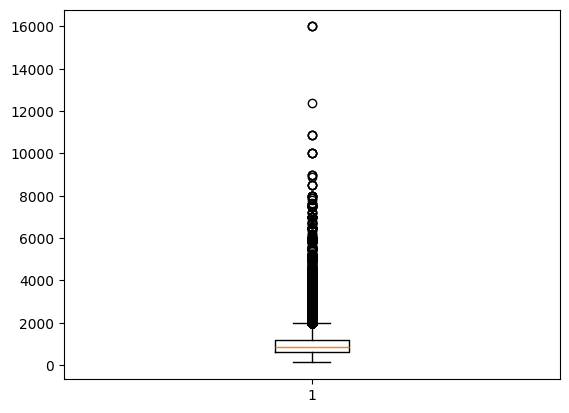

In [159]:
plt.boxplot(house_prices['area'])
plt.show()

In [160]:
house_prices_scaled = house_prices.copy()

In [161]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
house_prices_scaled[['area']] = scaler.fit_transform(house_prices_scaled[['area']])

In [162]:
house_prices_scaled.head()

,bhk,locality,area,price,region,age,type_Apartment,type_Other,type_Studio Apartment,type_Villa,status_Ready to move,status_Under Construction
0,3,Lak And Hanware The Residency Tower,-0.506566,250.00,Andheri West,0,1,0,0,0,1,0
1,2,Radheya Sai Enclave Building No 2,-0.573703,52.51,Naigaon East,0,1,0,0,0,0,1
2,2,Romell Serene,-0.618461,173.00,Borivali West,0,1,0,0,0,0,1
3,2,Soundlines Codename Urban Rainforest,-0.221607,59.98,Panvel,0,1,0,0,0,0,1
4,2,Origin Oriana,-0.545356,94.11,Mira Road East,0,1,0,0,0,0,1


In [163]:
house_prices_scaled.locality.value_counts()

,count
locality,
Hiranandani Meadows,861
Sheth Avalon,516
T Bhimjyani The Verraton,499
ACME Ozone Phase 2,467
Runwal Gardens,389
...,...
Cosmos Angel Tower,1
Sheth Konark Empress,1
Shree Chamunda Garden,1


In [164]:
house_prices_scaled.locality.describe()

,locality
count,76038
unique,9782
top,Hiranandani Meadows
freq,861


In [165]:
locality_target = house_prices.groupby('locality')['price'].mean()
house_prices_scaled['locality'] = house_prices['locality'].map(locality_target)
house_prices['locality'] = house_prices['locality'].map(locality_target)

In [166]:
house_prices.head()

,bhk,locality,area,price,region,age,type_Apartment,type_Other,type_Studio Apartment,type_Villa,status_Ready to move,status_Under Construction
0,3,130.500000,685,250.00,Andheri West,0,1,0,0,0,1,0
1,2,42.852500,640,52.51,Naigaon East,0,1,0,0,0,0,1
2,2,207.461538,610,173.00,Borivali West,0,1,0,0,0,0,1
3,2,59.980000,876,59.98,Panvel,0,1,0,0,0,0,1
4,2,92.480833,659,94.11,Mira Road East,0,1,0,0,0,0,1


In [167]:
region_target = house_prices.groupby('region')['price'].mean()
house_prices_scaled['region'] = house_prices['region'].map(region_target)
house_prices['region'] = house_prices['region'].map(region_target)

In [168]:
house_prices.head()

,bhk,locality,area,price,region,age,type_Apartment,type_Other,type_Studio Apartment,type_Villa,status_Ready to move,status_Under Construction
0,3,130.500000,685,250.00,326.839007,0,1,0,0,0,1,0
1,2,42.852500,640,52.51,38.391204,0,1,0,0,0,0,1
2,2,207.461538,610,173.00,211.395800,0,1,0,0,0,0,1
3,2,59.980000,876,59.98,85.735583,0,1,0,0,0,0,1
4,2,92.480833,659,94.11,81.412477,0,1,0,0,0,0,1


In [169]:
house_prices.age.value_counts()

,count
age,
0,38072
1,23357
2,14609


In [170]:
house_prices_scaled.head()

,bhk,locality,area,price,region,age,type_Apartment,type_Other,type_Studio Apartment,type_Villa,status_Ready to move,status_Under Construction
0,3,130.500000,-0.506566,250.00,326.839007,0,1,0,0,0,1,0
1,2,42.852500,-0.573703,52.51,38.391204,0,1,0,0,0,0,1
2,2,207.461538,-0.618461,173.00,211.395800,0,1,0,0,0,0,1
3,2,59.980000,-0.221607,59.98,85.735583,0,1,0,0,0,0,1
4,2,92.480833,-0.545356,94.11,81.412477,0,1,0,0,0,0,1


In [171]:
X = house_prices.drop('price', axis=1)
Y = house_prices['price']
X_  = house_prices_scaled.drop('price', axis=1)
Y_  = house_prices_scaled['price']

In [172]:
X_Train,X_Test,Y_Train,Y_Test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [173]:
x_train,x_test,y_train,y_test = train_test_split(X_,Y_,test_size=0.2,random_state=2)

In [174]:
lin_reg = LinearRegression()
lasso_reg = Lasso()
ridge_reg = Ridge()
xgb_reg = XGBRegressor()
dt_reg = DecisionTreeRegressor()
rf_reg = RandomForestRegressor()


In [175]:
X_Train.isna().sum()

,0
bhk,0
locality,0
area,0
region,0
age,0
type_Apartment,0
type_Other,0
type_Studio Apartment,0
type_Villa,0
status_Ready to move,0


In [176]:
lin_reg.fit(X_Train,Y_Train)
lasso_reg.fit(X_Train,Y_Train)
ridge_reg.fit(X_Train,Y_Train)


Ridge()

In [177]:
xgb_reg.fit(x_train,y_train)
dt_reg.fit(x_train,y_train)
rf_reg.fit(x_train,y_train)

RandomForestRegressor()

In [178]:
train_prediction1 = lin_reg.predict(X_Train)
train_prediction2 = lasso_reg.predict(X_Train)
train_prediction3 = ridge_reg.predict(X_Train)
train_prediction4 = xgb_reg.predict(x_train)
train_prediction5 = dt_reg.predict(x_train)
train_prediction6 = rf_reg.predict(x_train)


In [179]:
test_prediction1 = lin_reg.predict(X_Test)
test_prediction2 = lasso_reg.predict(X_Test)
test_prediction3 = ridge_reg.predict(X_Test)
test_prediction4 = xgb_reg.predict(x_test)
test_prediction5 = dt_reg.predict(x_test)
test_prediction6 = rf_reg.predict(x_test)

In [180]:
score1 = metrics.r2_score(Y_Train,train_prediction1)
score2 = metrics.r2_score(Y_Train,train_prediction2)
score3 = metrics.r2_score(Y_Train,train_prediction3)
score4 = metrics.r2_score(y_train,train_prediction4)
score5 = metrics.r2_score(y_train,train_prediction5)
score6 = metrics.r2_score(y_train,train_prediction6)


In [181]:
print(score1,score2,score3,score4,score5,score6)

0.8822401341712226 0.8818680750255719 0.8822401340256164 0.9753095980950022 0.9973765190471146 0.9906850507490705


In [182]:
score1 = metrics.r2_score(Y_Test,test_prediction1)
score2 = metrics.r2_score(Y_Test,test_prediction2)
score3 = metrics.r2_score(Y_Test,test_prediction3)
score4 = metrics.r2_score(y_test,test_prediction4)
score5 = metrics.r2_score(y_test,test_prediction5)
score6 = metrics.r2_score(y_test,test_prediction6)
print(score1,score2,score3,score4,score5,score6)


0.8678370637404851 0.8674791936892788 0.8678371626616644 0.9222039557671377 0.9127150697166411 0.9423937771623023


In [183]:
y_pred = rf_reg.predict(x_test)
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison.head(10)

,Actual,Predicted
44537,75.0,77.628600
54707,162.0,150.640000
33616,236.0,235.196667
10735,800.0,722.725000
75123,88.0,96.100000
875,20.0,20.000000
13194,86.0,87.540000
54679,295.0,248.794167
338,20.0,20.000000
70184,144.0,133.530000


In [184]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean absolute Error:", mae)

Mean absolute Error: 14.414287297174699


In [185]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred)
print("Mean absolute percentage error:", mape)

Mean absolute percentage error: 0.07824103505596817


/tmp/ipykernel_1729/2243153716.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-y_pred)


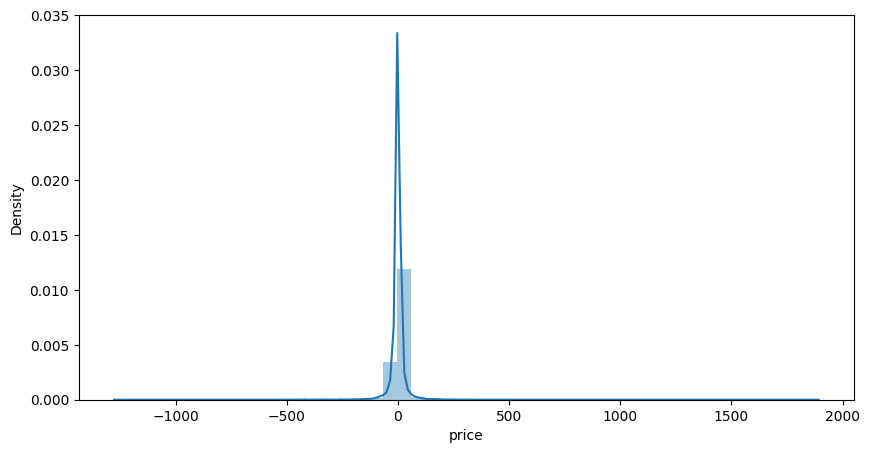

In [186]:
plt.figure(figsize=(10,5))
sns.distplot(y_test-y_pred)
plt.show()

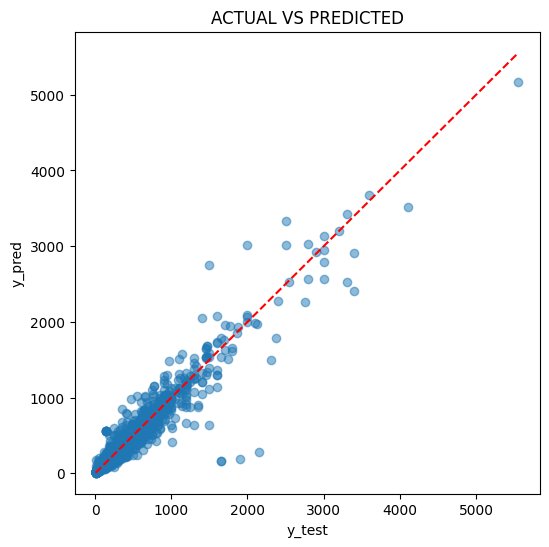

In [187]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.title("ACTUAL VS PREDICTED")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()

In [188]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# rf = RandomForestRegressor(random_state=42)
# params_dist = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [20,30],
#     "min_samples_split": [2, 5],
#     "min_samples_leaf": [1, 2],
#     "max_features": ["sqrt"],
#     'bootstrap': [True]
# }

# random_search = RandomizedSearchCV(estimator= rf, param_distributions=params_dist, n_iter=15, cv=5,scoring="r2", random_state=42, n_jobs=2,verbose=2)
# random_search.fit(x_train, y_train)
# print("Best Parameters")
# best_params = random_search.best_params_
# print(best_params)
# best_score = random_search.best_score_
# print("Best Score")
# print(best_score)
# best_rf = random_search.best_estimator_
# best_rf = RandomForestRegressor(
#     bootstrap=True,
#     max_depth=None,
#     max_features='sqrt',
#     min_samples_leaf=2,
#     min_samples_split=3,
#     n_estimators=200,
#     random_state=42,
#     n_jobs = -1)
# best_rf.fit(x_train, y_train)





In [229]:
rf_reg = RandomForestRegressor(
    n_estimators=25,
    random_state=42,
    n_jobs = -1
)
rf_reg.fit(x_train, y_train)

RandomForestRegressor(n_estimators=25, n_jobs=-1, random_state=42)

In [231]:
test = rf_reg.predict(x_test)
mape1 = mean_absolute_percentage_error(y_test, test)
print("Mean absolute percentage error:", mape1)
r2score = metrics.r2_score(y_test, test)
print("R2 score:", r2score)
mae1 = mean_absolute_error(y_test, test)
print("Mean absolute Error:", mae1)

Mean absolute percentage error: 0.07917117695587902
R2 score: 0.9406992844233852
Mean absolute Error: 14.604761616796544


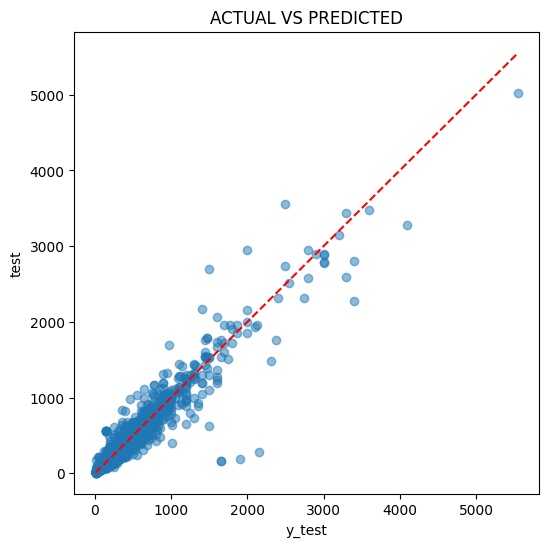

In [232]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,test,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("test")
plt.title("ACTUAL VS PREDICTED")

min_val = min(y_test.min(), test.min())
max_val = max(y_test.max(), test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()

In [233]:
import pickle as pkl
pkl.dump(rf_reg,open('house_price_model.pkl','wb'))

In [193]:
house_prices1 = pd.read_csv('/content/Mumbai House Prices.csv')

In [194]:
locality_dict = (
    house_prices1.groupby('locality')['price'].mean().to_dict()
)
region_dict = (
    house_prices1.groupby('region')['price'].mean().to_dict()
)

locality_dict = {
    k.lower().replace(' ', ''): v for k, v in locality_dict.items()
}
region_dict = {
    k.lower().replace(' ', ''): v for k, v in region_dict.items()
}
pkl.dump(locality_dict, open('locality_dict.pkl', 'wb'))
pkl.dump(region_dict, open('region_dict.pkl', 'wb'))


In [195]:
house_prices1.head()

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [196]:
print(list(locality_dict.items()))

[('ajshrijay', 62.0), ('akruti', 20.0), ('amberheights', 28.0), ('arcade', 62.375), ('asburypark', 3.266666666666667), ('ashanagar', 1.2666666666666666), ('batulhouse', 1.75), ('burlington', 3.2), ('chandradarshansky', 54.333333333333336), ('crest', 6.725), ('daffodil', 65.0), ('daisy', 45.0), ('dwarkeshdhamchs', 90.0), ('emporioapartments', 2.8666666666666667), ('estatecardinal', 2.9023529411764706), ('euphoria', 66.0), ('greenfield', 70.0), ('greenwoodsbuilding2to6', 58.0), ('harsiddhiapartment', 43.0), ('heights', 57.0), ('hillsresidency', 2.0225), ('jbheights', 40.0), ('jainamelysium', 1.7042857142857142), ('kvkcoral', 50.0), ('kartikregency', 1.25), ('lords', 1.25), ('mahaveertowers', 75.0), ('mahavirastha', 1.3), ('mayflower', 2.0208695652173914), ('miracleheights', 1.75), ('muktamahek', 1.51), ('omdhara', 63.333333333333336), ('pride', 1.48), ('qamarenclave', 1.95), ('radhekrishnaheights', 20.6), ('rajapartment', 22.5), ('residency', 21.0), ('riddhisiddhiapartment', 48.0), ('roy

In [197]:
region_locality_dict = {}
for region in house_prices1['region'].dropna().unique():
    localities = (
        house_prices1[house_prices1['region'] == region]['locality'].dropna().unique().tolist()
    )
    region_locality_dict[
        region
    ] = sorted(
        localities

    )


In [198]:
print(list(region_locality_dict.items()))

[('Andheri West', ['ACME Stadium View', 'AVN Silver Skyline', 'Aashna Kamal Dutt CHSL', 'Adani Codename Westbay', 'Adani Codename Westbay Phase I', 'Adani Estates Western Heights Phase 1 Residential', 'Adani Inspire Hub', 'Adani Western Heights Phase 1 Residential', 'Advantage Park Plaza', 'Advantage Windermere', 'Agarwal Shishira Tower', 'Ahuja Dhanlaxmi', 'Ajmera Beverly Hills and Royal Empire', 'Ajmera Divyam Heights', 'Ajmera Florida', 'Ajmera Golden Rays', 'Ajmera Royal Classic', 'Ajmera Shastri Nagar', 'Anmol Eleganzia Royale', 'Antariksh Alba', 'Arrow Marvel Heights Enigma A1', 'Aryaman Tanish', 'Ashray Minarette', 'Asshna Seabliss', 'Avinash Builders Avinash Tower', 'Bajaj Enchante Panchsheel CHSL', 'Beverly Hill Beverly Hill', 'Bharat Skyvistas', 'Blue Castle Fiona', 'Chaitanya Anand Lunkhod CHSL', 'Chandiwala Pearl Heaven', 'Chandiwala Pearl Height', 'Cosmic Sea Shell Apartment', 'Cosmos Cosmopolis', 'Crystal Atlantis', 'Crystal Harmony', 'D Kapoor Land Silver Arch', 'DLH Dar

In [199]:
print(region_locality_dict["Fort"])

['Aplite Greenstone Heritage', 'Aplite Greenstone Heritage Wing D', 'Aplite Greenstone Heritage Wing E And F']


In [200]:
pkl.dump(region_locality_dict, open('region_locality_dict.pkl', 'wb'))

In [201]:
print(x_train.columns.tolist())

['bhk', 'locality', 'area', 'region', 'age', 'type_Apartment', 'type_Other', 'type_Studio Apartment', 'type_Villa', 'status_Ready to move', 'status_Under Construction']


In [202]:
print(list(region_locality_dict.keys()))

['Andheri West', 'Naigaon East', 'Borivali West', 'Panvel', 'Mira Road East', 'Parel', 'Boisar', 'Santacruz East', 'Badlapur East', 'Fort', 'Badlapur West', 'Khopoli', 'Chembur', 'Jogeshwari West', 'Vasai', 'Kalamboli', 'Powai', 'Ghansoli', 'Thane West', 'Vikhroli', 'Bhiwandi', 'Airoli', 'Ambernath West', 'Borivali East', 'Virar', 'Kharghar', 'Ulwe', 'Kamothe', 'Jogeshwari East', 'Mulund West', 'Palghar', 'Goregaon West', 'Taloja', 'Rasayani', 'Ghatkopar East', 'Ulhasnagar', 'Dombivali', 'Kewale', 'Nala Sopara', 'Goregaon East', 'Kandivali East', 'Kurla', 'Andheri East', 'Dahisar', 'Karanjade', 'Mahim', 'Vashi', 'Malad West', 'Girgaon', 'Dadar West', 'Bandra West', 'Kandivali West', 'Kalyan West', 'Neral', 'Kalyan East', 'Karjat', 'Ghatkopar West', 'Dronagiri', 'Mulund East', 'Navade', 'Ambivali', 'Agripada', 'Owale', 'Ville Parle East', 'Kalwa', 'Khar', 'Santacruz West', 'Nerul', 'Kanjurmarg', 'Vangani', 'Bhayandar East', 'Seawoods', 'Sewri', 'Ambernath East', 'Nilje Gaon', 'Prabhadev

In [235]:
from google.colab import files
files.download('house_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [234]:
import os

print(os.path.getsize("house_price_model.pkl") / (1024**3))

0.08501123357564211


In [220]:
print(X_Train.columns)
print(len(X_Train.columns))

Index(['bhk', 'locality', 'area', 'region', 'age', 'type_Apartment',
       'type_Other', 'type_Studio Apartment', 'type_Villa',
       'status_Ready to move', 'status_Under Construction'],
      dtype='object')
11


In [223]:
print(len(rf_reg.estimators_))

50


In [224]:
import os
print(os.path.getsize("house_price_model.pkl") / (1024 * 1024))

174.23106002807617
